In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [52]:
import yfinance as yf

tickers = {
    "target":     ["^GSPC"],
    "volatility": ["^VIX", "^TNX", "^FVX"],
    "indices":    ["^IXIC", "^DJI", "^RUT"],
    "sectors":    ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLB", "XLU", "XLRE"],
    "commodities":["GC=F", "CL=F", "SI=F"],
    "fx":         ["DX-Y.NYB"],
}

all_tickers = [t for group in tickers.values() for t in group]

raw = yf.download(all_tickers, start="2015-01-01", auto_adjust=True)["Close"]

raw = raw.dropna(thresh=int(len(raw) * 0.95), axis=1)

rename_map = {
    "^GSPC":    "spx",
    "^VIX":     "vix",
    "^TNX":     "yield_10y",
    "^FVX":     "yield_5y",
    "^IXIC":    "nasdaq",
    "^DJI":     "dow",
    "^RUT":     "russell",
    "GC=F":     "gold",
    "CL=F":     "oil",
    "SI=F":     "silver",
    "DX-Y.NYB": "usd_index",
}
raw = raw.rename(columns={k: v for k, v in rename_map.items() if k in raw.columns})

returns = np.log(raw / raw.shift(1)).dropna()

returns["target"] = returns["spx"].shift(-1)
returns = returns.dropna()

[*********************100%***********************]  21 of 21 completed


In [53]:
returns

Ticker,oil,usd_index,gold,silver,XLB,XLE,XLF,XLI,XLK,XLP,...,XLV,XLY,dow,yield_5y,spx,nasdaq,russell,yield_10y,vix,target
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.051603,0.003288,0.014980,0.027890,-0.025819,-0.042248,-0.021251,-0.023636,-0.015383,-0.007057,...,-0.005113,-0.019311,-0.018755,-0.031390,-0.018447,-0.015831,-0.014663,-0.040371,0.113088,-0.008933
2015-01-06,-0.043081,0.001312,0.012711,0.025869,-0.008898,-0.014800,-0.015401,-0.012397,-0.012130,-0.001250,...,-0.003374,-0.010013,-0.007456,-0.049013,-0.008933,-0.012943,-0.017109,-0.037986,0.058496,0.011563
2015-01-07,0.014910,0.004253,-0.007161,-0.005617,0.011216,0.002127,0.010432,0.007493,0.008433,0.016957,...,0.023240,0.015690,0.012180,-0.013486,0.011563,0.012491,0.012545,-0.004595,-0.089597,0.017730
2015-01-08,0.002874,0.005210,-0.001819,-0.009677,0.023502,0.022201,0.014833,0.019831,0.021742,0.015059,...,0.016941,0.014890,0.018221,0.015494,0.017730,0.018265,0.016998,0.031237,-0.126822,-0.008439
2015-01-09,-0.008852,-0.004666,0.006270,0.002138,-0.005153,-0.007957,-0.013589,-0.010768,-0.003146,-0.008112,...,-0.008933,-0.011640,-0.009567,-0.036071,-0.008439,-0.006805,-0.008775,-0.022574,0.031252,-0.008127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-21,-0.019630,0.000807,0.001874,0.007395,0.006016,-0.011267,0.001354,-0.001172,0.008208,-0.010107,...,0.006909,0.006423,0.005510,0.007545,0.001714,0.000865,0.009214,0.003057,-0.039771,0.003720
2026-05-22,0.002591,0.001310,-0.004150,-0.006842,0.005383,0.006070,0.004051,0.007245,0.009972,0.001652,...,0.011676,0.004036,0.005830,-0.000235,0.003720,0.001933,0.009026,-0.006124,-0.003586,0.000165
2026-05-27,-0.057089,0.000403,-0.011824,-0.022611,0.003719,-0.014978,-0.008328,0.000000,-0.003842,0.011296,...,0.001884,0.017428,0.003612,-0.001435,0.000165,0.000696,-0.000205,-0.002674,-0.043250,0.005737


In [70]:
returns.index

DatetimeIndex(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14',
               '2015-01-15', '2015-01-16',
               ...
               '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19',
               '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-27',
               '2026-05-28', '2026-05-29'],
              dtype='datetime64[ns]', name='Date', length=2854, freq=None)

In [73]:
test = returns.loc['2026-01-01':'2026-05-29']
train = returns.loc['2015-01-01':"2025-12-31"]

In [68]:
X = returns.drop(columns=["target"])
y = returns["target"]
X

Ticker,oil,usd_index,gold,silver,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,dow,yield_5y,spx,nasdaq,russell,yield_10y,vix
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.051603,0.003288,0.014980,0.027890,-0.025819,-0.042248,-0.021251,-0.023636,-0.015383,-0.007057,-0.012301,-0.005113,-0.019311,-0.018755,-0.031390,-0.018447,-0.015831,-0.014663,-0.040371,0.113088
2015-01-06,-0.043081,0.001312,0.012711,0.025869,-0.008898,-0.014800,-0.015401,-0.012397,-0.012130,-0.001250,0.000640,-0.003374,-0.010013,-0.007456,-0.049013,-0.008933,-0.012943,-0.017109,-0.037986,0.058496
2015-01-07,0.014910,0.004253,-0.007161,-0.005617,0.011216,0.002127,0.010432,0.007493,0.008433,0.016957,0.009762,0.023240,0.015690,0.012180,-0.013486,0.011563,0.012491,0.012545,-0.004595,-0.089597
2015-01-08,0.002874,0.005210,-0.001819,-0.009677,0.023502,0.022201,0.014833,0.019831,0.021742,0.015059,0.006945,0.016941,0.014890,0.018221,0.015494,0.017730,0.018265,0.016998,0.031237,-0.126822
2015-01-09,-0.008852,-0.004666,0.006270,0.002138,-0.005153,-0.007957,-0.013589,-0.010768,-0.003146,-0.008112,-0.006312,-0.008933,-0.011640,-0.009567,-0.036071,-0.008439,-0.006805,-0.008775,-0.022574,0.031252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-21,-0.019630,0.000807,0.001874,0.007395,0.006016,-0.011267,0.001354,-0.001172,0.008208,-0.010107,0.010949,0.006909,0.006423,0.005510,0.007545,0.001714,0.000865,0.009214,0.003057,-0.039771
2026-05-22,0.002591,0.001310,-0.004150,-0.006842,0.005383,0.006070,0.004051,0.007245,0.009972,0.001652,0.007748,0.011676,0.004036,0.005830,-0.000235,0.003720,0.001933,0.009026,-0.006124,-0.003586
2026-05-27,-0.057089,0.000403,-0.011824,-0.022611,0.003719,-0.014978,-0.008328,0.000000,-0.003842,0.011296,-0.004200,0.001884,0.017428,0.003612,-0.001435,0.000165,0.000696,-0.000205,-0.002674,-0.043250


In [ ]:
target_corr = X.corrwith(y).abs()
weak = target_corr[target_corr < 0.01].index.tolist()
X_filtered = X.drop(columns=weak)

In [75]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# --- PCA: retain 95% of variance ---
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced to {X_pca.shape[1]} components from {X_filtered.shape[1]} features")
print(f"Variance explained per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

# --- Loadings: which features drive each PC? ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_filtered.columns,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
print(f"\nTop 5 features driving PC1:\n{loadings['PC1'].abs().sort_values(ascending=False).head()}")

PCA reduced to 11 components from 20 features
Variance explained per component:
  PC1: 0.517  (cumulative: 0.517)
  PC2: 0.124  (cumulative: 0.641)
  PC3: 0.079  (cumulative: 0.720)
  PC4: 0.054  (cumulative: 0.775)
  PC5: 0.052  (cumulative: 0.827)
  PC6: 0.038  (cumulative: 0.865)
  PC7: 0.027  (cumulative: 0.892)
  PC8: 0.021  (cumulative: 0.913)
  PC9: 0.018  (cumulative: 0.930)
  PC10: 0.014  (cumulative: 0.944)
  PC11: 0.011  (cumulative: 0.955)

Top 5 features driving PC1:
Ticker
spx        0.304755
dow        0.301519
XLI        0.288627
russell    0.280959
nasdaq     0.277558
Name: PC1, dtype: float64


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

In [76]:
from sklearn.model_selection import  KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])

X = X_filtered.values
y_vals = y.values

tscv = TimeSeriesSplit(n_splits=5)
ts_scores = cross_val_score(pipe, X, y_vals, cv=tscv, scoring="neg_mean_squared_error")


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(pipe, X, y_vals, cv=kfold, scoring="neg_mean_squared_error")

print(f"TimeSeriesSplit MSE: {-ts_scores.mean():.6f} ± {ts_scores.std():.6f}")
print(f"KFold MSE:          {-kf_scores.mean():.6f} ± {kf_scores.std():.6f}")

TimeSeriesSplit MSE: 0.000135 ± 0.000069
KFold MSE:          0.000125 ± 0.000010


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

lasso_selector = LassoCV(cv=tscv, max_iter=10000, random_state=42)
lasso_selector.fit(X_scaled, y)

selected_mask = lasso_selector.coef_ != 0
selected_features = X_filtered.columns[selected_mask].tolist()

X_selected = X_scaled[:, selected_mask]
print(f"LASSO selected {len(selected_features)} features (alpha={lasso_selector.alpha_:.5f}):")
coef_series = pd.Series(lasso_selector.coef_[selected_mask], index=selected_features)
print(coef_series.sort_values(key=abs, ascending=False))

LASSO selected 13 features (alpha=0.00012):
spx         -0.000938
vix         -0.000868
yield_10y   -0.000810
XLP         -0.000479
XLI          0.000438
XLU         -0.000431
XLK         -0.000430
XLV         -0.000246
silver       0.000221
XLF         -0.000216
XLY          0.000208
usd_index   -0.000085
XLE         -0.000064
dtype: float64


In [60]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

models = {
    "OLS":   LinearRegression(),
    "Ridge": RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=tscv),
    "LASSO": LassoCV(cv=tscv, max_iter=10000, random_state=42),
}

inputs = {
    "OLS":   X_selected,
    "Ridge": X_selected,
    "LASSO": X_scaled,
}

results = {}

for name, model in models.items():
    X_in = inputs[name]
    mse_scores, mae_scores, dir_scores = [], [], []

    for train_idx, val_idx in tscv.split(X_in):
        X_train, X_val = X_in[train_idx], X_in[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mse_scores.append(mean_squared_error(y_val, y_pred))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        dir_scores.append(np.mean(np.sign(y_pred) == np.sign(y_val)))

    results[name] = {
        "MSE":      np.mean(mse_scores),
        "MAE":      np.mean(mae_scores),
        "Dir Acc":  np.mean(dir_scores),
        "MSE std":  np.std(mse_scores),
    }

naive_mse, naive_dir = [], []
for _, val_idx in tscv.split(X_scaled):
    y_val = y.iloc[val_idx]
    naive_mse.append(mean_squared_error(y_val, np.zeros(len(y_val))))
    naive_dir.append(np.mean(np.sign(np.zeros(len(y_val))) == np.sign(y_val)))

results["Naive (0)"] = {
    "MSE":     np.mean(naive_mse),
    "MAE":     np.mean(naive_mse),
    "Dir Acc": np.mean(naive_dir),
    "MSE std": np.std(naive_mse),
}

results_df = pd.DataFrame(results).T
results_df = results_df.round(6)
print("\n=============== Model Comparison ===============")
print(results_df.to_string())



=============== Model Comparison ===============
                MSE       MAE   Dir Acc   MSE std
OLS        0.000134  0.007633  0.528000  0.000071
Ridge      0.000133  0.007497  0.526316  0.000074
LASSO      0.000134  0.007470  0.536421  0.000078
Naive (0)  0.000134  0.000134  0.000421  0.000081


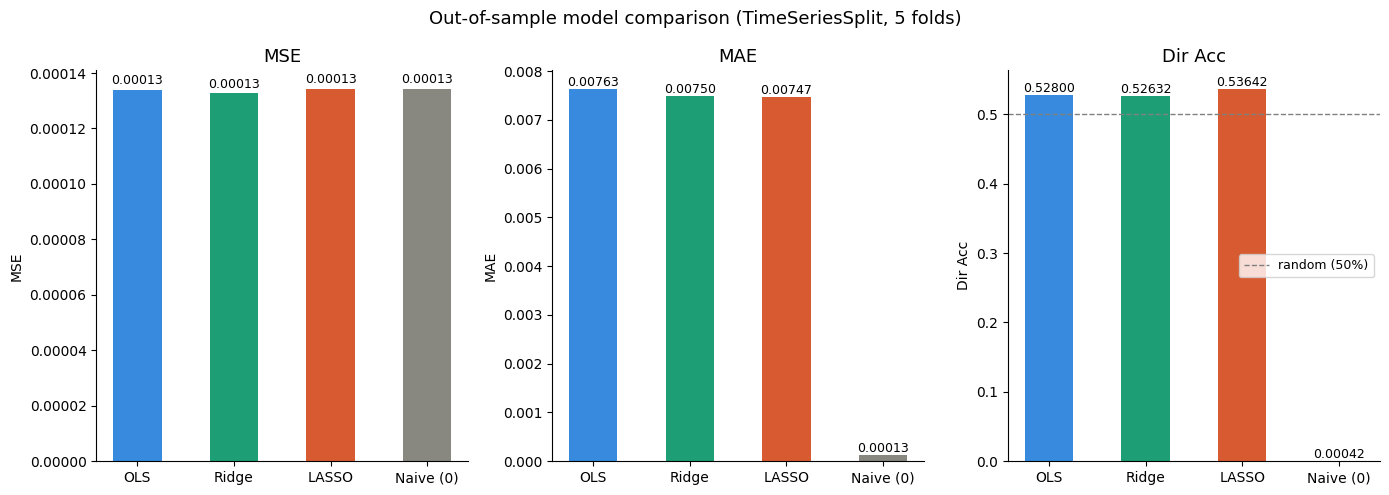

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = list(results.keys())
colors = ["#378ADD", "#1D9E75", "#D85A30", "#888780"]

for ax, metric in zip(axes, ["MSE", "MAE", "Dir Acc"]):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000001,
                f"{val:.5f}", ha="center", va="bottom", fontsize=9)
    if metric == "Dir Acc":
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random (50%)")
        ax.legend(fontsize=9)

plt.suptitle("Out-of-sample model comparison (TimeSeriesSplit, 5 folds)", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



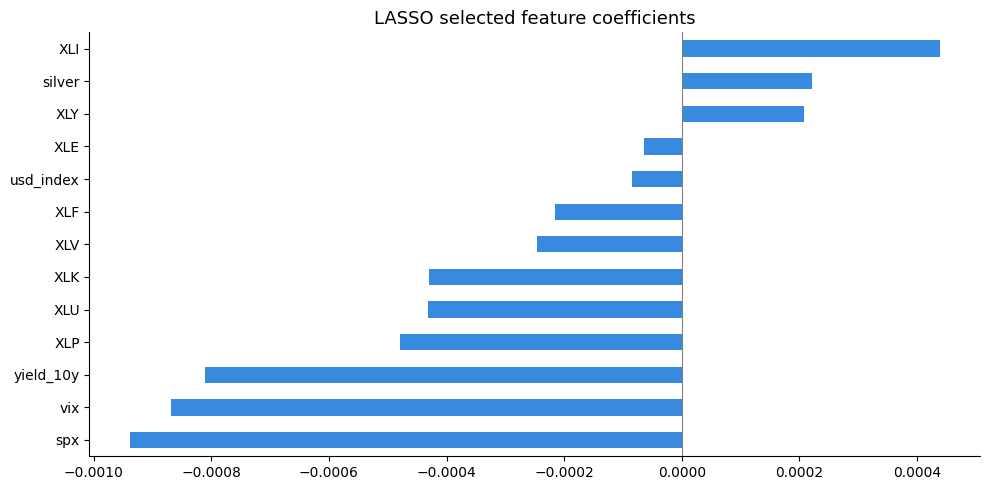

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
coef_series.sort_values().plot(kind="barh", ax=ax, color="#378ADD")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("LASSO selected feature coefficients", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lasso_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()